# 04 分子性质预测：从 baseline 到随机森林

这一节用 ESOL 做回归任务：输入分子特征，预测 logS。

应用场景：在合成、药物发现或材料筛选中，先用已有数据估计候选分子的性质，再决定哪些分子值得进一步实验。
本节使用 scikit-learn 的 `DummyRegressor`、`Ridge` 和 `RandomForestRegressor` 做轻量比较；数据仍来自 Delaney ESOL。

## 直觉解释

建模前先做 baseline。baseline 回答：“如果模型什么结构都不学，只预测训练集均值，表现如何？”任何复杂模型都应该和 baseline 比。

化学解释上，baseline 是“没有利用结构信息”的参照；Ridge 尝试用 descriptor 的线性组合解释 logS；
RandomForest 可以捕捉非线性关系，但也更容易在小数据上记住局部模式。

## 数学/化学定义

RMSE：

```text
RMSE = sqrt(mean((y_true - y_pred)^2))
```

MAE：

```text
MAE = mean(abs(y_true - y_pred))
```

parity plot：横轴真实值，纵轴预测值；点越接近对角线，预测越准。

## 准备数据和模型工具

这一部分读取 ESOL 派生特征，把 descriptor 表变成 `X`，把 logS 变成 `y`，并做一个 random train/test split。
注意：random split 只是在这一数据分布内做插值评估，不能证明模型能外推到新骨架。

In [1]:
from pathlib import Path

START = Path.cwd().resolve()
for candidate in [START, *START.parents]:
    if (candidate / "data").exists() and (candidate / "notebooks").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Cannot find the materials root. Start Jupyter from the materials directory "
        "or from one of its subdirectories."
    )

DATA = ROOT / "data"
RAW = DATA / "raw"
EXAMPLES = DATA / "examples"
RANDOM_STATE = 42

# print("materials root:", ROOT)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Crippen, Descriptors, Draw, Lipinski, rdFingerprintGenerator, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

sns.set_theme(style="whitegrid", context="notebook")


def mol_from_smiles(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(str(smiles).strip())


def canonical_smiles(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)


def scaffold_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


def descriptor_record(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "canonical_smiles": canonical_smiles(smiles),
        "scaffold": scaffold_smiles(mol),
    }


def build_esol_features():
    raw = pd.read_csv(RAW / "esol.csv")
    rows = []
    for row_id, row in raw.reset_index(drop=True).iterrows():
        desc = descriptor_record(row["smiles"])
        if desc is None:
            continue
        desc.update(
            {
                "row_id": row_id,
                "smiles": str(row["smiles"]).strip(),
                "logS": float(row["log solubility (mol/L)"]),
            }
        )
        rows.append(desc)
    return pd.DataFrame(rows)


def fingerprint_array(smiles, n_bits=1024):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    matrix = np.zeros((len(smiles), n_bits), dtype=np.int8)
    for idx, smi in enumerate(smiles):
        fp = generator.GetFingerprint(mol_from_smiles(smi))
        DataStructs.ConvertToNumpyArray(fp, matrix[idx])
    return matrix


DESCRIPTOR_COLUMNS = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3",
    "HeavyAtomCount",
]

In [3]:
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# X 是分子 descriptor 矩阵；y 是实验 logS 标签。
esol = build_esol_features()
X = esol[DESCRIPTOR_COLUMNS].to_numpy(dtype=float)
y = esol["logS"].to_numpy(dtype=float)

# 这里先用 random split 训练入门模型；更严格的 scaffold split 放到下一章。
train_idx, test_idx = train_test_split(np.arange(len(esol)), test_size=0.2, random_state=RANDOM_STATE)
print(len(train_idx), "train rows;", len(test_idx), "test rows")

902 train rows; 226 test rows


## 代码

比较三个模型：均值 baseline、线性 Ridge、RandomForestRegressor。

In [4]:
models = {
    "Baseline mean": DummyRegressor(strategy="mean"),
    "Ridge descriptors": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "RandomForest descriptors": RandomForestRegressor(n_estimators=60, random_state=RANDOM_STATE, n_jobs=-1),
}

rows = []
predictions = {}
for name, estimator in models.items():
    # clone 确保每个模型都是未训练的新实例，避免上一个模型状态泄漏。
    model = clone(estimator)
    model.fit(X[train_idx], y[train_idx])
    pred_train = model.predict(X[train_idx])
    pred_test = model.predict(X[test_idx])
    predictions[name] = pred_test
    rows.append(
        {
            "model": name,
            "train_RMSE": mean_squared_error(y[train_idx], pred_train) ** 0.5,
            "test_RMSE": mean_squared_error(y[test_idx], pred_test) ** 0.5,
            "test_MAE": mean_absolute_error(y[test_idx], pred_test),
            "test_R2": r2_score(y[test_idx], pred_test),
        }
    )

results = pd.DataFrame(rows).sort_values("test_RMSE")
results.round(3)

,model,train_RMSE,test_RMSE,test_MAE,test_R2
2,RandomForest descriptors,0.271,0.800,0.551,0.865
1,Ridge descriptors,0.938,1.037,0.781,0.772
0,Baseline mean,2.075,2.174,1.732,-0.000


## 读 parity plot

这一格选择 test RMSE 最低的模型，画出真实 logS 与预测 logS。对角线不是拟合线，
而是“完美预测线”；偏离越远，误差越大。

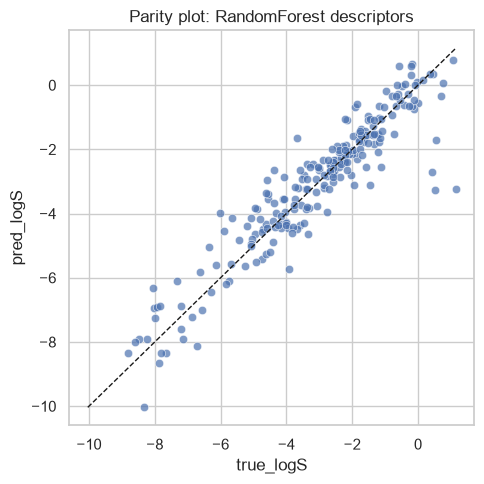

In [5]:
best_name = results.iloc[0]["model"]
plot_df = pd.DataFrame(
    {
        "true_logS": y[test_idx],
        "pred_logS": predictions[best_name],
        "smiles": esol.iloc[test_idx]["smiles"].to_numpy(),
    }
)

plt.figure(figsize=(5, 5))
sns.scatterplot(data=plot_df, x="true_logS", y="pred_logS", alpha=0.7)
lims = [min(plot_df["true_logS"].min(), plot_df["pred_logS"].min()), max(plot_df["true_logS"].max(), plot_df["pred_logS"].max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.title(f"Parity plot: {best_name}")
plt.tight_layout()

## 找最难预测的分子

模型平均分数只能告诉我们整体误差。还需要检查失败样例：
它们是否更大、更疏水、官能团特殊，或者落在训练集中少见的结构区域？

,true_logS,pred_logS,abs_error,smiles
106,1.144,-3.232,4.376,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
137,0.523,-3.281,3.804,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl
168,0.430,-2.719,3.149,CCOP(=O)(OCC)OCC
11,0.540,-1.697,2.237,COP(=O)(NC(C)=O)SC
145,-3.685,-1.636,2.049,Cc3cc2nc1c(=O)[nH]c(=O)nc1n(CC(O)C(O)C(O)CO)c2...
215,-6.020,-3.979,2.041,Fc1cccc(F)c1C(=O)NC(=O)Nc2ccc(Cl)cc2


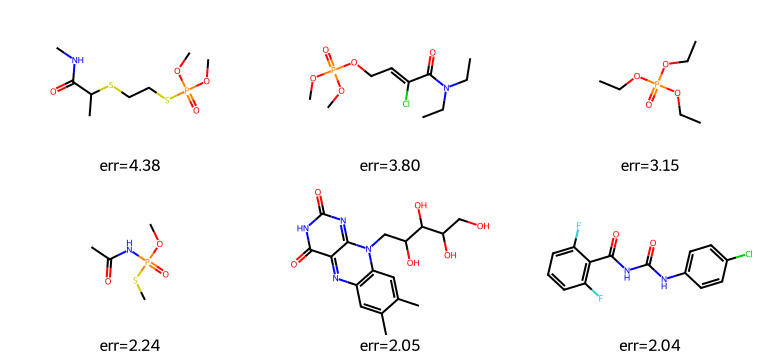

In [6]:
# abs_error 帮我们找到这次 test split 中预测偏差最大的分子。
plot_df["abs_error"] = (plot_df["true_logS"] - plot_df["pred_logS"]).abs()
worst = plot_df.sort_values("abs_error", ascending=False).head(6)
display(worst[["true_logS", "pred_logS", "abs_error", "smiles"]].round(3))

Draw.MolsToGridImage(
    [mol_from_smiles(s) for s in worst["smiles"]],
    legends=[f"err={e:.2f}" for e in worst["abs_error"]],
    molsPerRow=3,
    subImgSize=(260, 180),
)

## 观察问题

1. RandomForestRegressor 是否一定比 Ridge 好？
2. train RMSE 和 test RMSE 差很多时，可能意味着什么？
3. 最差预测样例有什么共同结构或 descriptor 特征？

### Hints

1. 不一定。RandomForest 能表达非线性，但在小数据、弱特征或分布外测试时不保证更好。
2. train 很低、test 明显更高通常提示过拟合，或者测试集和训练集分布不同。
3. 可以回到 descriptor 表看 MolWt、MolLogP、TPSA、HBD/HBA，也可以观察是否有大环、多个杂原子、强疏水片段或训练集中少见结构。

## 小结

性质预测要先建立 baseline，再比较模型。RMSE 和 parity plot 是读懂回归结果的起点，但它们还不能回答模型是否能外推到新骨架。